# Improvise generator

Using similar scripts as the other documents but focused on generating sheet music.

Let's get started with `import`s.

In [17]:
import random
from music21 import harmony, key, meter, note, pitch, stream, tempo
from IPython.display import Image

Now, let's define our key `dict` to map a key string to the appropriate amount of flats/sharps.

In [53]:
KEYS = {
	"cb": -7, "gb": -6, "db": -5, "ab": -4, "eb": -3, "bb": -2, "f": -1,
	"c": 0, "g": 1, "d": 2, "a": 3, "e": 4, "b": 5, "f#": 6, "c#": 7
}

TIME_SIGS = {
	"2/2": [2, 2], "2/4": [2, 1], "3/4": [3, 1], "4/4": [4, 1],
	"5/4": [5, 1], "6/8": [ 6, 0.5], "9/8": [9, 0.5]
}

NOTE_LENGTHS = {
  "whole": 4, "half": 2, "quarter": 1, "eighth": 0.5, "sixteenth": 0.25,
  "dotted_half": 3, "dotted_quarter": 1.5, "dotted_eighth": 0.75,
  "triplet_quarter": 0.333333, "triplet_half": 0.666666
}

NOTE_WEIGHTS = {
  "whole": 1, "half": 5, "quarter": 25, "eighth": 70, "sixteenth": 1,
  "dotted_half": 2, "dotted_quarter": 10, "dotted_eighth": 1,
  "triplet_quarter": 50, "triplet_half": 3
}

CHROMATICS = ["C", "C#", "D", "E-", "E", "F", "F#", "G", "G#", "A", "B-"]

Let's work on our generator.

In [72]:
class Generator:
	def __init__(self, song_key: str, time_sig: str, song_tempo: int, chord_progression: dict):
		self.song_key = key.KeySignature(KEYS[song_key.lower()])
		self.time_sig = meter.TimeSignature(time_sig) # type: ignore
		self.song_tempo = tempo.MetronomeMark(number=song_tempo)
		self.song_info = [self.song_key, self.time_sig, self.song_tempo]

		self.scale = self.song_key.asKey()
		self.scale_pitches = [p.name for p in self.scale.pitches]
		del self.scale_pitches[-1]
		self.scale_pitches = self._correct_pitch_names(self.scale_pitches)

		self.chord_progression = chord_progression
		
		self.song = stream.Score()
	
	def generate_song(self, style: str="simple", swing: bool = False) -> stream.Score:
		""" Generates the sheet music for a song. """

		score = stream.Score()
		part = stream.Part()

		for item in self.song_info:
			score.append(item)
			part.append(item)

		for measure_idx, chord_list in self.chord_progression.items():
			measure = stream.Measure()
			if len(chord_list) == 1:
				chord = harmony.ChordSymbol(chord_list[0])
				notes = self.simple_melody_generator(measure_idx, chord)

				measure.append(chord)
				for n in notes:
					measure.append(n)
			elif len(chord_list) == 2:
				pass
			elif len(chord_list) == 3:
				pass
			elif len(chord_list) == 4:
				pass
			part.append(measure)
		
		score.append(part)
	
		return score
	
	def simple_melody_generator(self, measure_idx: int, current_chord: harmony.ChordSymbol) -> list:
		""" Generates a simple melody, favoring chord-tones/scale-tones while featuring chromatic notes. """
		
		next_chord_symbol = self._get_next_chord_symbol(measure_idx, current_chord)
		target_note = self._get_target_note(next_chord_symbol)
		
		measure_length, note_length = TIME_SIGS[self.time_sig.ratioString]

		current_beat = 0
		pitches = []

		while current_beat < measure_length:
			current_note, current_length = self._get_random_note_package(measure_length, current_beat, current_chord)

			if current_length in (NOTE_LENGTHS["triplet_quarter"], NOTE_LENGTHS["triplet_half"]):
				triplet_notes = self._build_triplet_group(current_note, current_length, current_beat, current_chord)
				pitches.extend(triplet_notes)

				add_beat = 1 if current_length == NOTE_LENGTHS["triplet_quarter"] else 2
				current_beat += add_beat
			else:
				pitches.append([current_note, current_length])
				current_beat += current_length

		pitches = self._transpose_pitches(pitches)
		notes = self._create_notes_list(pitches)
		
		return notes
	
	def _get_chord_pitches(self, chord: harmony.ChordSymbol) -> list:
		""" Gets all notes in a given ChordSymbol. """

		pitches = []
		for p in chord.pitches:
			p = str(p).replace("4", "5").replace("3", "4").replace("2", "3").replace("1", "2")
			pitches.append(p)
		
		return pitches
	
	def _get_next_chord_symbol(self, measure_idx: int, current_chord: harmony.ChordSymbol) -> harmony.ChordSymbol:
		""" Retrieves the next ChordSymbol in a progression, if available. """

		next_chord_symbol = current_chord

		if measure_idx != len(list(self.chord_progression.keys())):
			next_chord_symbol = harmony.ChordSymbol(self.chord_progression[measure_idx + 1][0])
		
		return next_chord_symbol
	
	def _get_target_note(self, chord: harmony.ChordSymbol) -> pitch.Pitch:
		""" Just as likely to get a third or fifth from a ChordSymbol. """

		target_note = chord.third if random.random() < 0.5 else chord.seventh

		return target_note # type: ignore
	
	def _get_favored_scale_note(self, chord: harmony.ChordSymbol) -> pitch.Pitch:
		""" Returns a note, favoring chord tones and scale tones. """

		chord_pitches = self._get_chord_pitches(chord)
		weights = []
		for n in CHROMATICS:
			weight = 1
			if n in chord_pitches: weight += 4
			if n in self.scale_pitches: weight += 3
			weights.append(weight)
		
		return pitch.Pitch(random.choices(CHROMATICS, weights=weights, k=1)[0])
	
	def _get_random_note(self, chord: harmony.ChordSymbol, current_beat: float) -> list:
		""" Returns a random note and note length. """

		start_note = self._get_target_note(chord) if current_beat == 0 else self._get_favored_scale_note(chord)
		start_length = random.choices(list(NOTE_LENGTHS.keys()), weights=[NOTE_WEIGHTS[k] for k in NOTE_LENGTHS.keys()])[0]

		return [start_note, NOTE_LENGTHS[start_length]]

	def _check_triplet_length(self, current_note: pitch.Pitch, current_length: float, measure_length: int, current_beat: float, chord: harmony.ChordSymbol) -> list:
		""" Gets a new length for a triplet if the whole triplet goes outside of the length of the measure. """

		while (current_length == NOTE_LENGTHS["triplet_quarter"] and 1 > measure_length - current_beat) or (current_length == NOTE_LENGTHS["triplet_half"] and 2 > measure_length - current_beat) or (current_length > measure_length - current_beat):
			_, current_length = self._get_random_note(chord, current_beat)
		
		return [current_note, current_length]
	
	def _check_triplet_beat(self, current_note: pitch.Pitch, current_length: float, current_beat: float, chord: harmony.ChordSymbol) -> list:
		""" Only begins triplets on appropriate beats. """

		while (current_length == NOTE_LENGTHS["triplet_quarter"] and current_beat not in [0, 1, 2, 3]) or (current_length == NOTE_LENGTHS["triplet_half"] and current_beat not in [0, 2]):
			_, current_length = self._get_random_note(chord, current_beat)
		
		return [current_note, current_length]
	
	def _get_random_note_package(self, measure_length: int, current_beat: float, chord: harmony.ChordSymbol) -> list:
		""" Gets a note pitch and length. """

		current_note, current_length = self._get_random_note(chord, current_beat)
		current_note, current_length = self._check_triplet_length(current_note, current_length, measure_length, current_beat, chord)
		current_note, current_length = self._check_triplet_beat(current_note, current_length, current_beat, chord)

		return [current_note, current_length]
	
	def _build_triplet_group(self, current_note: pitch.Pitch, current_length: float, current_beat: float, chord: harmony.ChordSymbol) -> list:
		""" If a note is a triplet, this gets the other two notes for the entire tuplet. """

		notes = [current_note]
		for _ in range(2):
			n, _ = self._get_random_note(chord, current_beat)
			notes.append(n)
		
		return [[n, current_length] for n in notes]
	
	def _transpose_pitches(self, pitches: list, semitones: int = 12) -> list:
		""" Shifts up pitches by an octave. """

		return [[p[0].transpose(semitones), p[1]] for p in pitches]
	
	def _create_notes_list(self, pitches: list) -> list:
		""" Create a list of notes from a list of pitches, note lengths. """

		return [note.Note(p[0], quarterLength=p[1]) for p in pitches]
	
	def _correct_pitch_names(self, pitches: list):
		""" Corrects pitch names in a pitches list if note names don't match the CHROMATICS constant. """

		MAP = {
			"C-": "B", "D-": "C#", "D#": "E-", "E#": "F", "G-": "F#", "A-": "G#", "A#": "B-"
		}

		new_pitches = []
		for p in pitches:
			if p in MAP:
				new_pitches.append(MAP[p])
			else:
				new_pitches.append(p)
		
		return new_pitches

	def print_song(self):
		""" Renders the sheet music as a transparent .png. """

		return Image(filename=self.song.write("musicxml.png"))

	def play_song(self):
		""" Plays the song as a midi file, excellent for playing in notebooks. """

		return self.song.show("midi")

In [73]:
song_key = "C"
time_sig = "4/4"
song_tempo = 120
progression = {
	1: ["Dm9"],
	2: ["G13"],
	3: ["CMaj9"],
	4: ["CMaj9"]
}

generator = Generator(song_key, time_sig, song_tempo, progression)
generator.song = generator.generate_song()

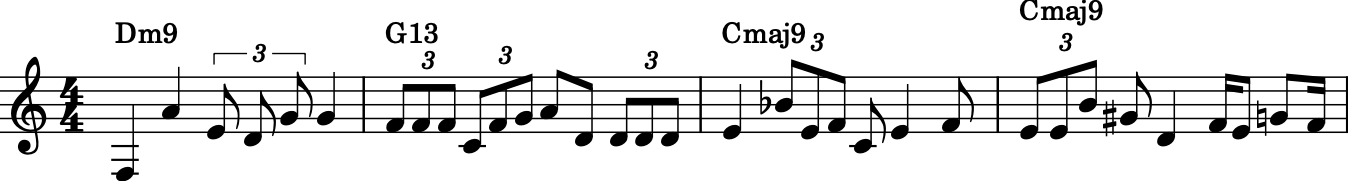

In [74]:
generator.print_song()

In [76]:
generator.play_song()